##### top

# FMP modelling for Figure 3 (Cue stimulus)

This notebook runs Bayesian models on Datasets 3 (dataset with randomising cue stimulus) that is described in the article to assess interaction between perception and memory difficulty levels in the FMP and to assess the effect of cue stimulus. We fit the following formulas to mean score within the condition. Throughout the notebook, I use `task` as a term for memory difficulty levels (M, UD, FD-e), `difficulty` as a term for perceptual difficulty levels (1, 2, 3), and `userID` as a variable denoting individual participants. The reference levels are UD level 1.

Unlike in `FMP_fit_linear_regression-Figure3-cue_stimulus.ipynb`, here we first separate the datasets according to the cue stimulus (`target_loc_simple` labels the morphing status of the cue stimulus; unmorphed = `target_0`, morphed = `other`) and subsequently fit models as before.


* Model task and difficulty interaction with user as a random effect. Equation:
    * _correct_flt ~ task * difficulty + (1|userID)_
* Model task and difficulty as main effects without interaction with user as a random effect. Equation:
    * _correct_flt ~ task + difficulty + (1|userID)_



We model mean accuracy per participant per condition.


* [Models](#Models)
* [Plot results](#Plot-results)
* [Compare all data](#Compare-all-data)
* [Save the inference](#Save-the-inference)


In [1]:
import os, sys
import pickle
from os.path import join as opj
import arviz as az
import bambi as bmb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-darkgrid")
SEED = 7355608


# Importing module for functions
functions_modul =  "./functions"
sys.path.insert(0, functions_modul)

# import all processing and plotting functions
from bayesian_modelling_functions import fit_model, print_model

path_general = "../"
path_data = opj(path_general, "Data", "datasets")
path_inference_data = opj(path_general, "Data", "model_inference_data")


# set the numer of CPU
num_cpu = min(4, os.cpu_count()-1)
print(f'We will have {num_cpu} cores.\n')

path_dic = {
#     'dataset_1' : opj(path_data, 'FMP_dataset_1.csv'),
#     'dataset_2': opj(path_data, 'FMP_dataset_2.csv'),
    'dataset_3': opj(path_data, 'FMP_dataset_3.csv'),
#     'concat_datasets_123': opj(path_data, 'FMP_concat_datasets_123.csv'),
#     'dataset_4': opj(path_data, 'FMP_dataset_4.csv'),
}


# load all dataframes
df_dic = {}

# only selected cols
select_cols = ['stim1', 'stim2', 'target', 'RT', 'userID', 'difficulty', 'levels', 'task', 'correct_flt', 'order']


for f in path_dic.keys():   
    if 'dataset_3' in f:
        df_dic[f] = pd.read_csv(path_dic[f], usecols=select_cols+['target_loc', 'target_loc_simple'])
    else:
        df_dic[f] = pd.read_csv(path_dic[f], usecols=select_cols)
    
    df_dic[f]["Experiment"] = f
        

    # clean
    df_dic[f].reset_index(drop=True, inplace=True)
    
    if 'Unnamed: 0' in df_dic[f].columns:
        df_dic[f].drop('Unnamed: 0', inplace=True, axis=1)
        
    
    # find low performing participants
    tt = df_dic[f].loc[df_dic[f]['task'].isin(['face matching', 'perc', 'perception'])].groupby(['userID', 'difficulty']).correct_flt.mean()

    drop_ptc = tt[tt<=0.5].reset_index().userID.values
    print(f'\nIn {f} dropping {len(drop_ptc)} participants for low accuracy in FM.')
    print(tt[tt<=0.5])

    # and remove them
    df_dic[f] = df_dic[f].loc[~df_dic[f]['userID'].isin(drop_ptc)]
    # clean up
    drop_ptc, tt = None, None
    
    print(f"\nThere is now N={df_dic[f]['userID'].unique().size} participants in {f}.")



#####
# rename the levels
rename_tasks_dic = {'perception':'Matching', 'perc':'Matching', 'blank':'Unfilled Delay', 'faces':'Filled Delay - emotions', 'math':'Filled Delay - math'}

# define orders
hue_order = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions']
hue_order_math = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions', 'Filled Delay - math']



# rename the memory task labels in the df
for f in df_dic.keys():
    if f=='noise':
        continue
    df_dic[f]['task'] = df_dic[f]['task'].map(rename_tasks_dic).fillna(df_dic[f]['task'])

    
    
# add two datasets for the longitudinal split based on cue stimuli (target) location
# take only other -> morphed
df_dic['dataset_3_other'] = df_dic['dataset_3'].loc[df_dic['dataset_3']['target_loc_simple']=='other'].copy()

# take only target 0 -> unmorphed
df_dic['dataset_3_target_0'] = df_dic['dataset_3'].loc[df_dic['dataset_3']['target_loc_simple']=='target_0'].copy()


We will have 4 cores.


In dataset_3 dropping 0 participants for low accuracy in FM.
Series([], Name: correct_flt, dtype: float64)

There is now N=262 participants in dataset_3.


In [2]:
# select only specific datasets and prepare them
datasets2fit = ['dataset_3_other', 'dataset_3_target_0']

df_dic_fit = {}


for f in datasets2fit:
    data=None
    
    # groupby and make means for ptc and condition
    data = df_dic[f].groupby(['userID', 'task', 'difficulty'], observed=False).correct_flt.mean().reset_index()

    # convert all variables to categories
    # categorical_cols = data.columns[data.dtypes == object].tolist() + ['difficulty']
    categorical_cols = ['userID', 'task', 'difficulty']
    for col in categorical_cols:
        if col == 'task':
            # specify the order that we want
            data[col] = pd.Categorical(data[col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions'], ordered=True)
            #['Unfilled Delay', 'Matching', 'Filled Delay - emotions']
            
            # also do it for the original datasets
            df_dic[f][col] = pd.Categorical(df_dic[f][col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions'], ordered=True)
        else:
            data[col] = data[col].astype("category")
            df_dic[f][col] = df_dic[f][col].astype("category")

    # check
    print('\n',f)
    df_dic[f].info()
        
    # save
    df_dic_fit[f] = data.copy()

# # drop them for now
# data[data.correct_flt.isna()]


 dataset_3_other
<class 'pandas.core.frame.DataFrame'>
Index: 12875 entries, 0 to 47155
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   stim1              12875 non-null  object  
 1   stim2              12875 non-null  object  
 2   target             12875 non-null  object  
 3   RT                 12517 non-null  float64 
 4   userID             12875 non-null  category
 5   task               12875 non-null  category
 6   order              12875 non-null  int64   
 7   difficulty         12875 non-null  category
 8   levels             12875 non-null  int64   
 9   correct_flt        12517 non-null  float64 
 10  target_loc_simple  12875 non-null  object  
 11  target_loc         12875 non-null  object  
 12  Experiment         12875 non-null  object  
dtypes: category(3), float64(2), int64(2), object(6)
memory usage: 1.1+ MB

 dataset_3_target_0
<class 'pandas.core.frame.DataFrame'>
Index: 34

## Models
[top](#top)

In [3]:
model_assumptions = {
    "correct_flt ~ task * difficulty + (1|userID)": "Each user has their own baseline performance, but the effect of task and difficulty is assumed to be the same across all users.",
    "correct_flt ~ task + difficulty + (1|userID)": "Assumes that each user has their own baseline performance, but the effects of task and difficulty are consistent across all users without any interaction between task and difficulty.",
}

# define what we want to run
formulas2run = [
    "correct_flt ~ task * difficulty + (1|userID)",
    "correct_flt ~ task + difficulty + (1|userID)",
]

In [4]:
# define where we will store the results
model_dic_bernoulli = {}
result_dic_bernoulli = {}

for f in df_dic_fit.keys():
    print(f'\nFitting dataset {f}\n')
    # create datasets
    if f not in model_dic_bernoulli.keys():
        model_dic_bernoulli[f] = {}
    if f not in result_dic_bernoulli.keys():
        result_dic_bernoulli[f] = {}
    
    for formula in formulas2run:
        print(f'\nFitting formula {formula}\n')
    
        model_dic_bernoulli[f][formula], result_dic_bernoulli[f][formula] = fit_model(formula, df_dic_fit[f], categorical_cols,
                                                                                      num_cpu=num_cpu, check_priors=False, sample_priors=False)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:22

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 23 seconds.


In [5]:
model_dic_bernoulli[f][formulas2run[0]]

       Formula: correct_flt ~ task * difficulty + (1|userID)
        Family: gaussian
          Link: mu = identity
  Observations: 2343
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.7701, sigma: 0.7843)
            task ~ Normal(mu: [0. 0.], sigma: [0.8887 0.893 ])
            difficulty ~ Normal(mu: [0. 0.], sigma: [0.8901 0.8901])
            task:difficulty ~ Normal(mu: [0. 0. 0. 0.], sigma: [1.3315 1.3315 1.3428 1.3428])
        
        Group-level effects
            1|userID ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.7843))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.1678)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

In [6]:
model_dic_bernoulli[f][formulas2run[1]]

       Formula: correct_flt ~ task + difficulty + (1|userID)
        Family: gaussian
          Link: mu = identity
  Observations: 2343
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.7701, sigma: 0.7262)
            task ~ Normal(mu: [0. 0.], sigma: [0.8887 0.893 ])
            difficulty ~ Normal(mu: [0. 0.], sigma: [0.8901 0.8901])
        
        Group-level effects
            1|userID ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.7262))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.1678)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

### check priors

Sampling: [1|userID_sigma, Intercept, difficulty, sigma, task, task:difficulty]


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'task\nMatching'}>],
       [<Axes: title={'center': 'task\nFilled Delay - emotions'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': 'task:difficulty\nMatching, 2'}>,
        <Axes: title={'center': 'task:difficulty\nMatching, 3'}>,
        <Axes: title={'center': 'task:difficulty\nFilled Delay - emotions, 2'}>],
       [<Axes: title={'center': 'task:difficulty\nFilled Delay - emotions, 3'}>,
        <Axes: title={'center': '1|userID_sigma'}>, <Axes: >]],
      dtype=object)

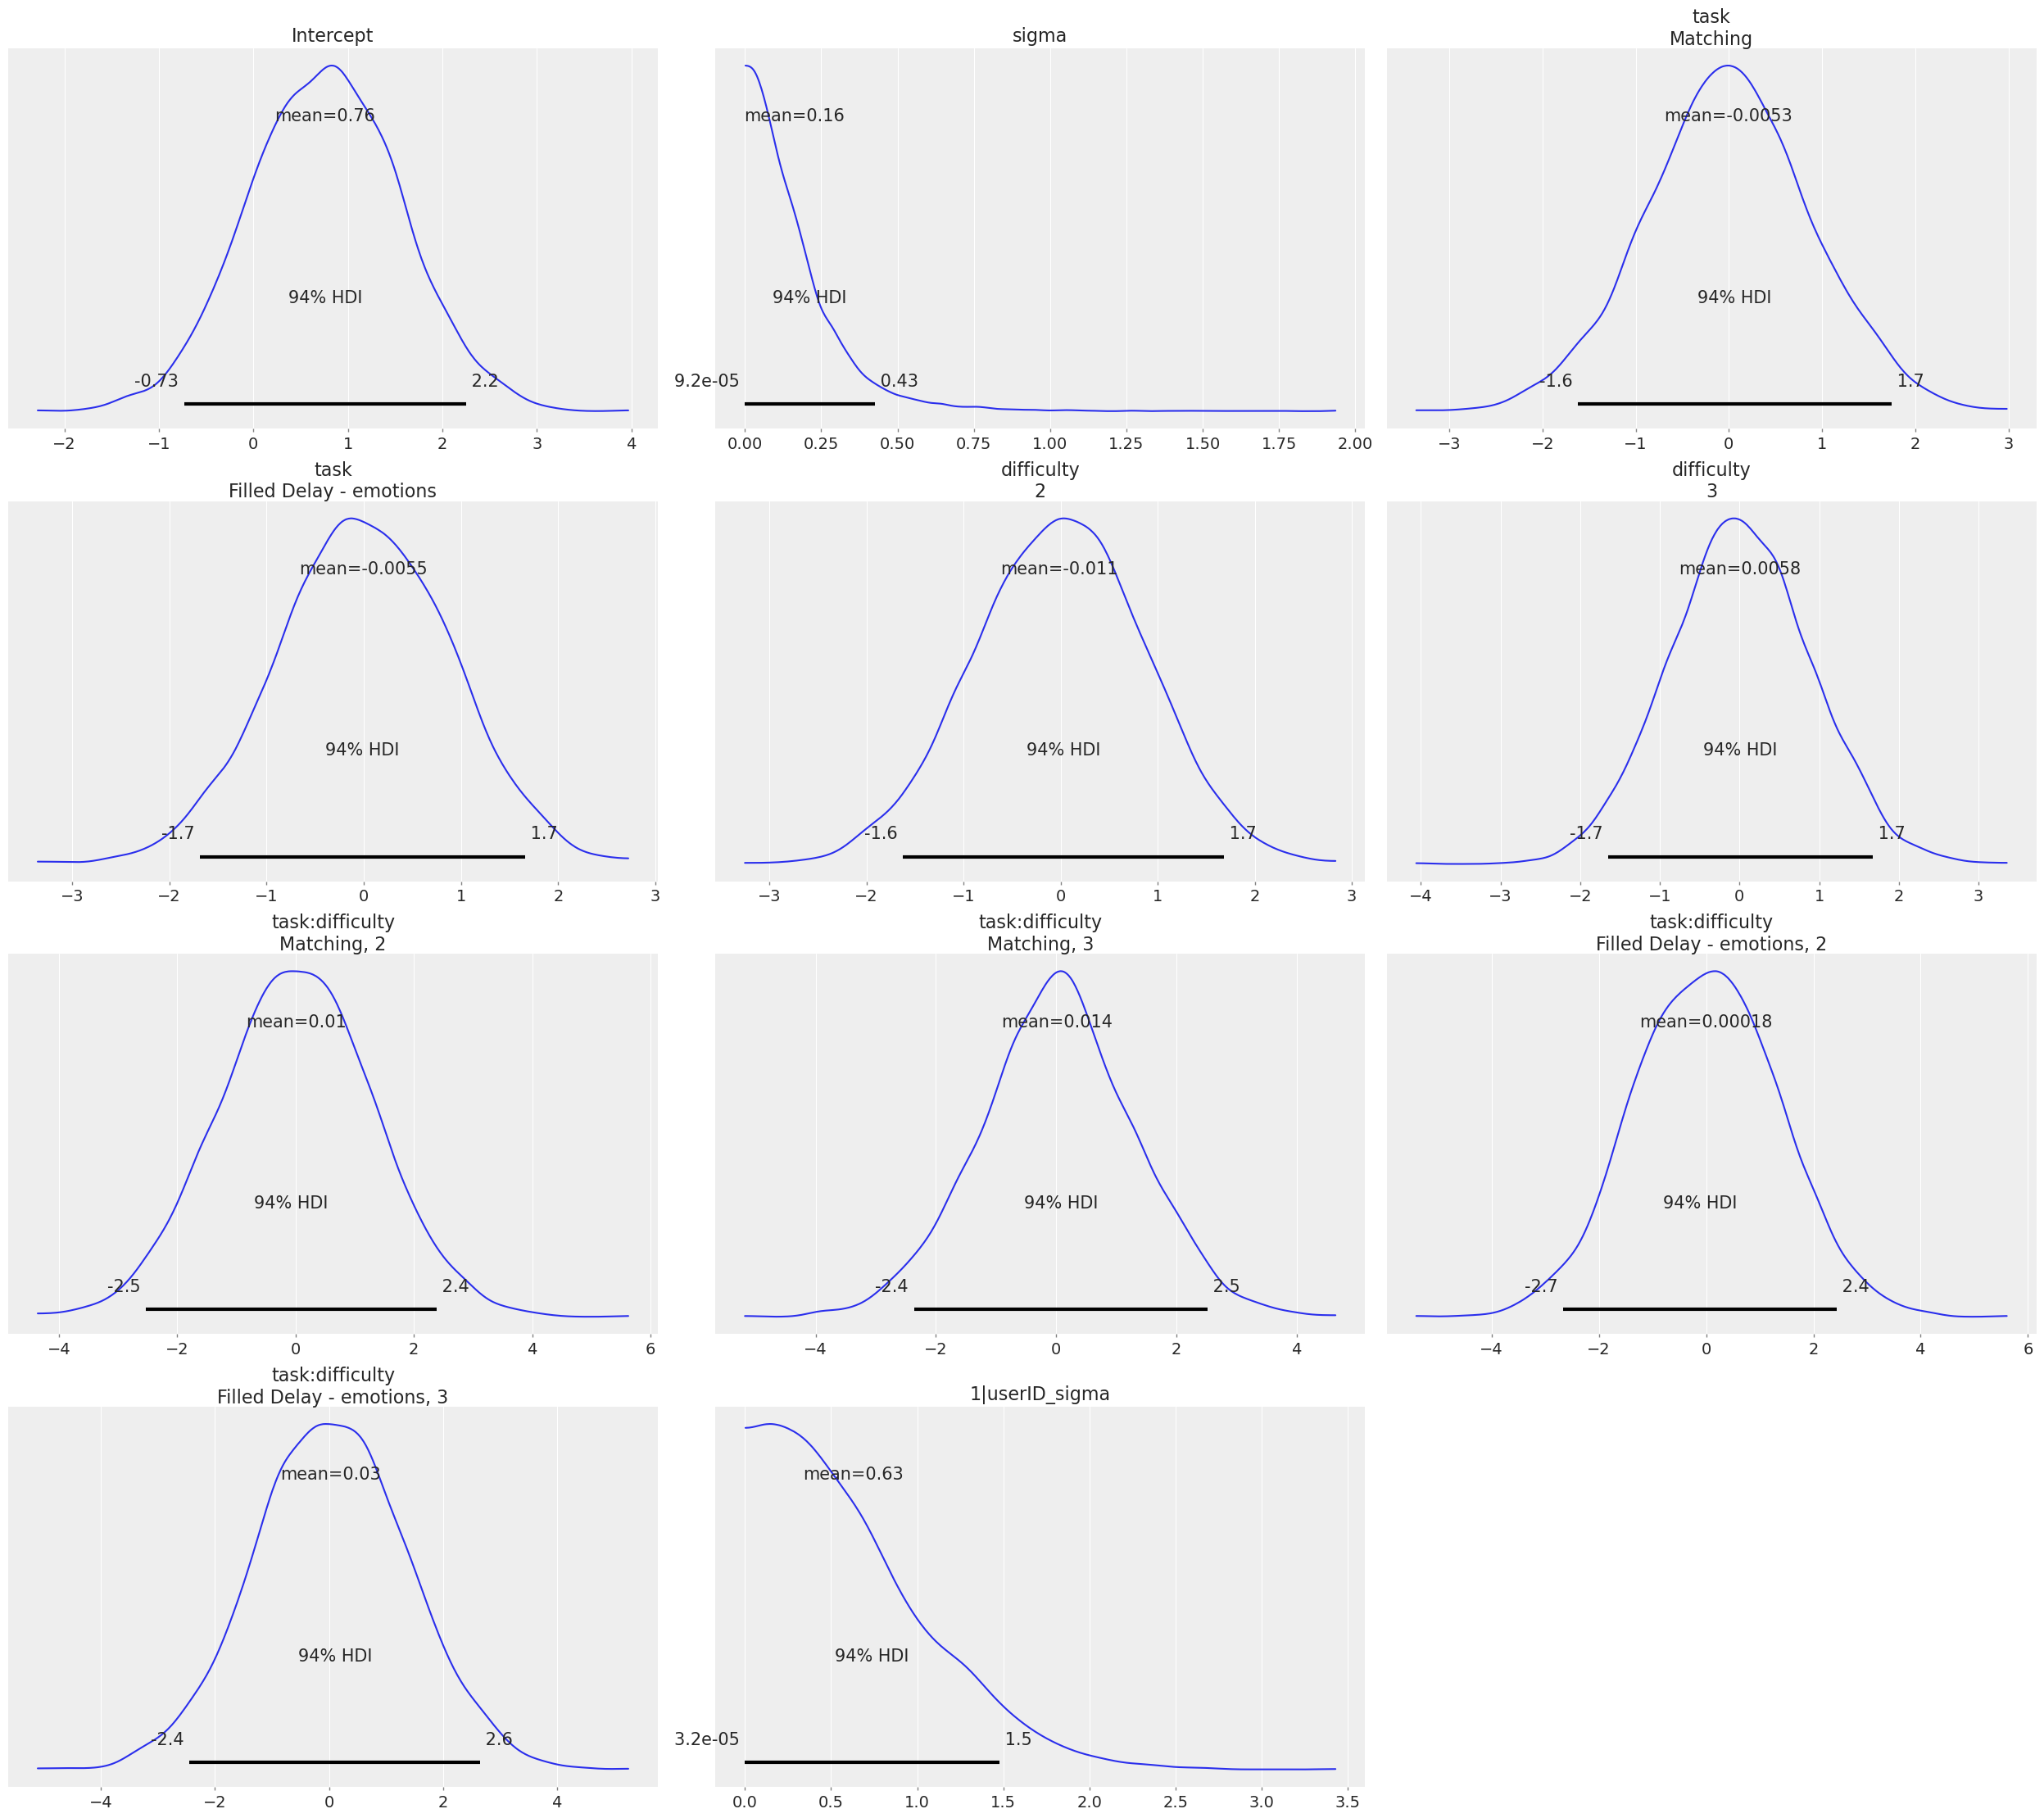

In [7]:
model_dic_bernoulli[f][formulas2run[0]].plot_priors()

Sampling: [1|userID_sigma, Intercept, difficulty, sigma, task]


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'task\nMatching'}>],
       [<Axes: title={'center': 'task\nFilled Delay - emotions'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': '1|userID_sigma'}>, <Axes: >, <Axes: >]],
      dtype=object)

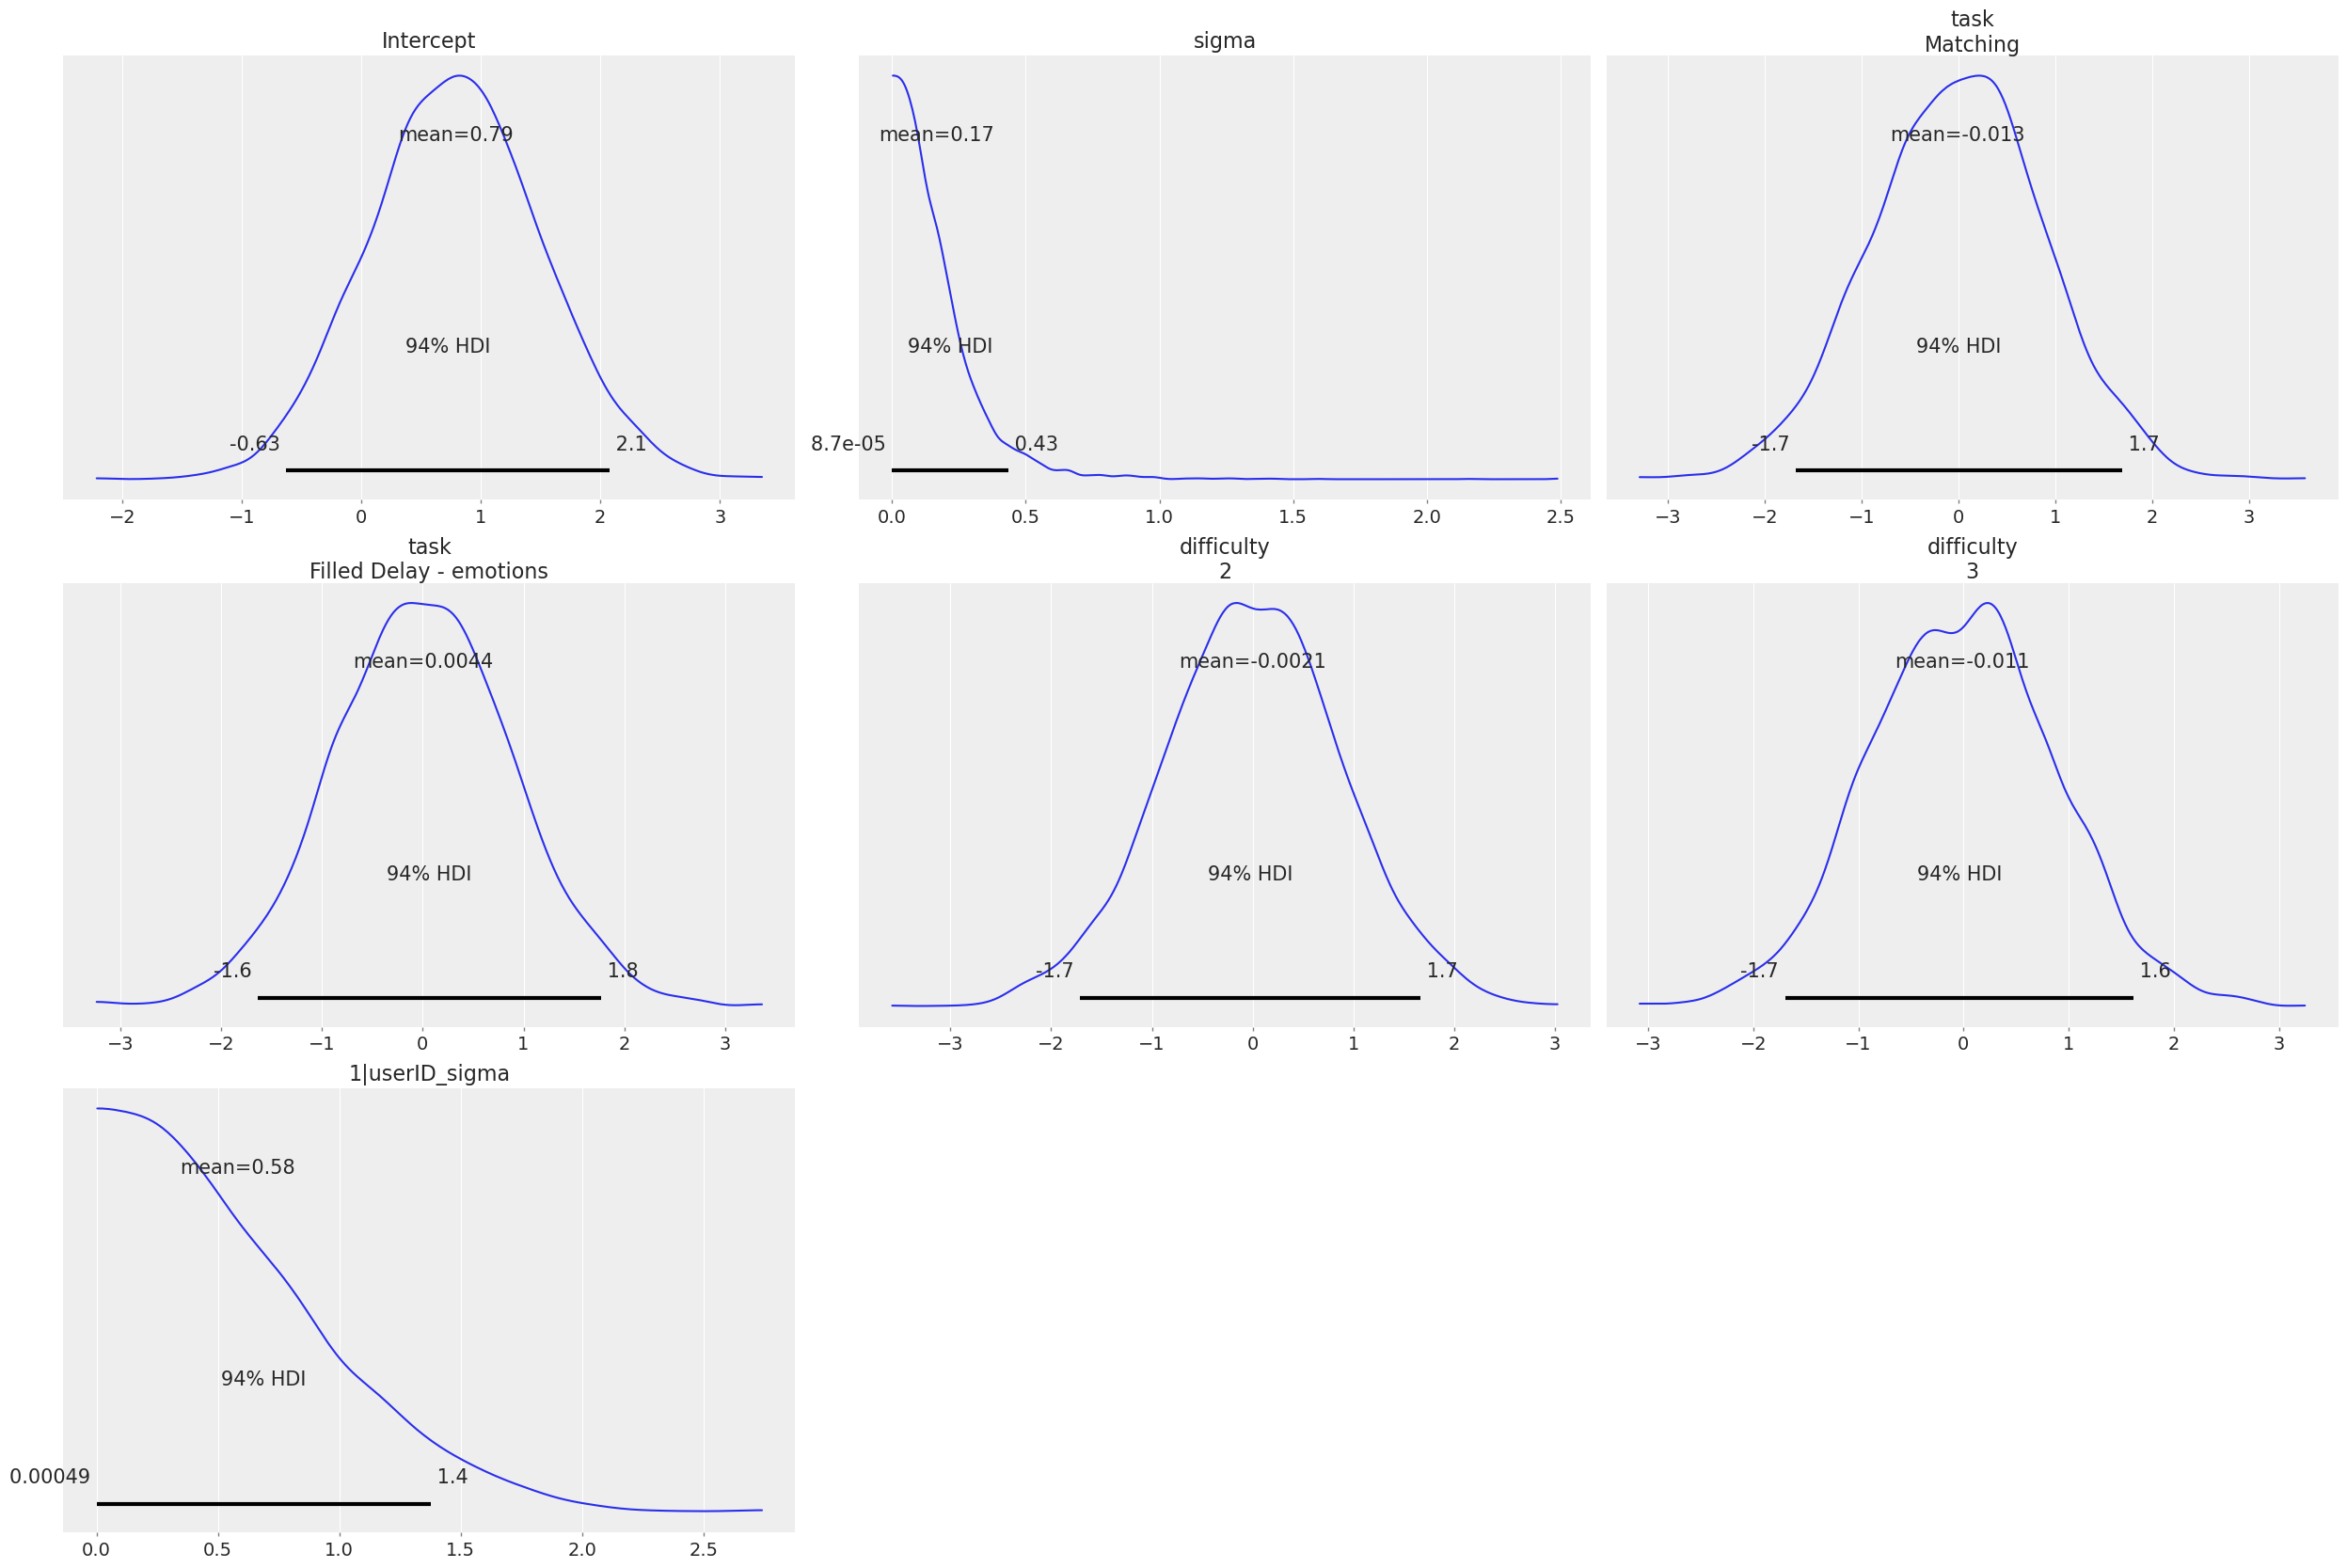

In [8]:
model_dic_bernoulli[f][formulas2run[1]].plot_priors()

### check posterior

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': 'task\nMatching'}>,
        <Axes: title={'center': 'task\nFilled Delay - emotions'}>,
        <Axes: >]], dtype=object)

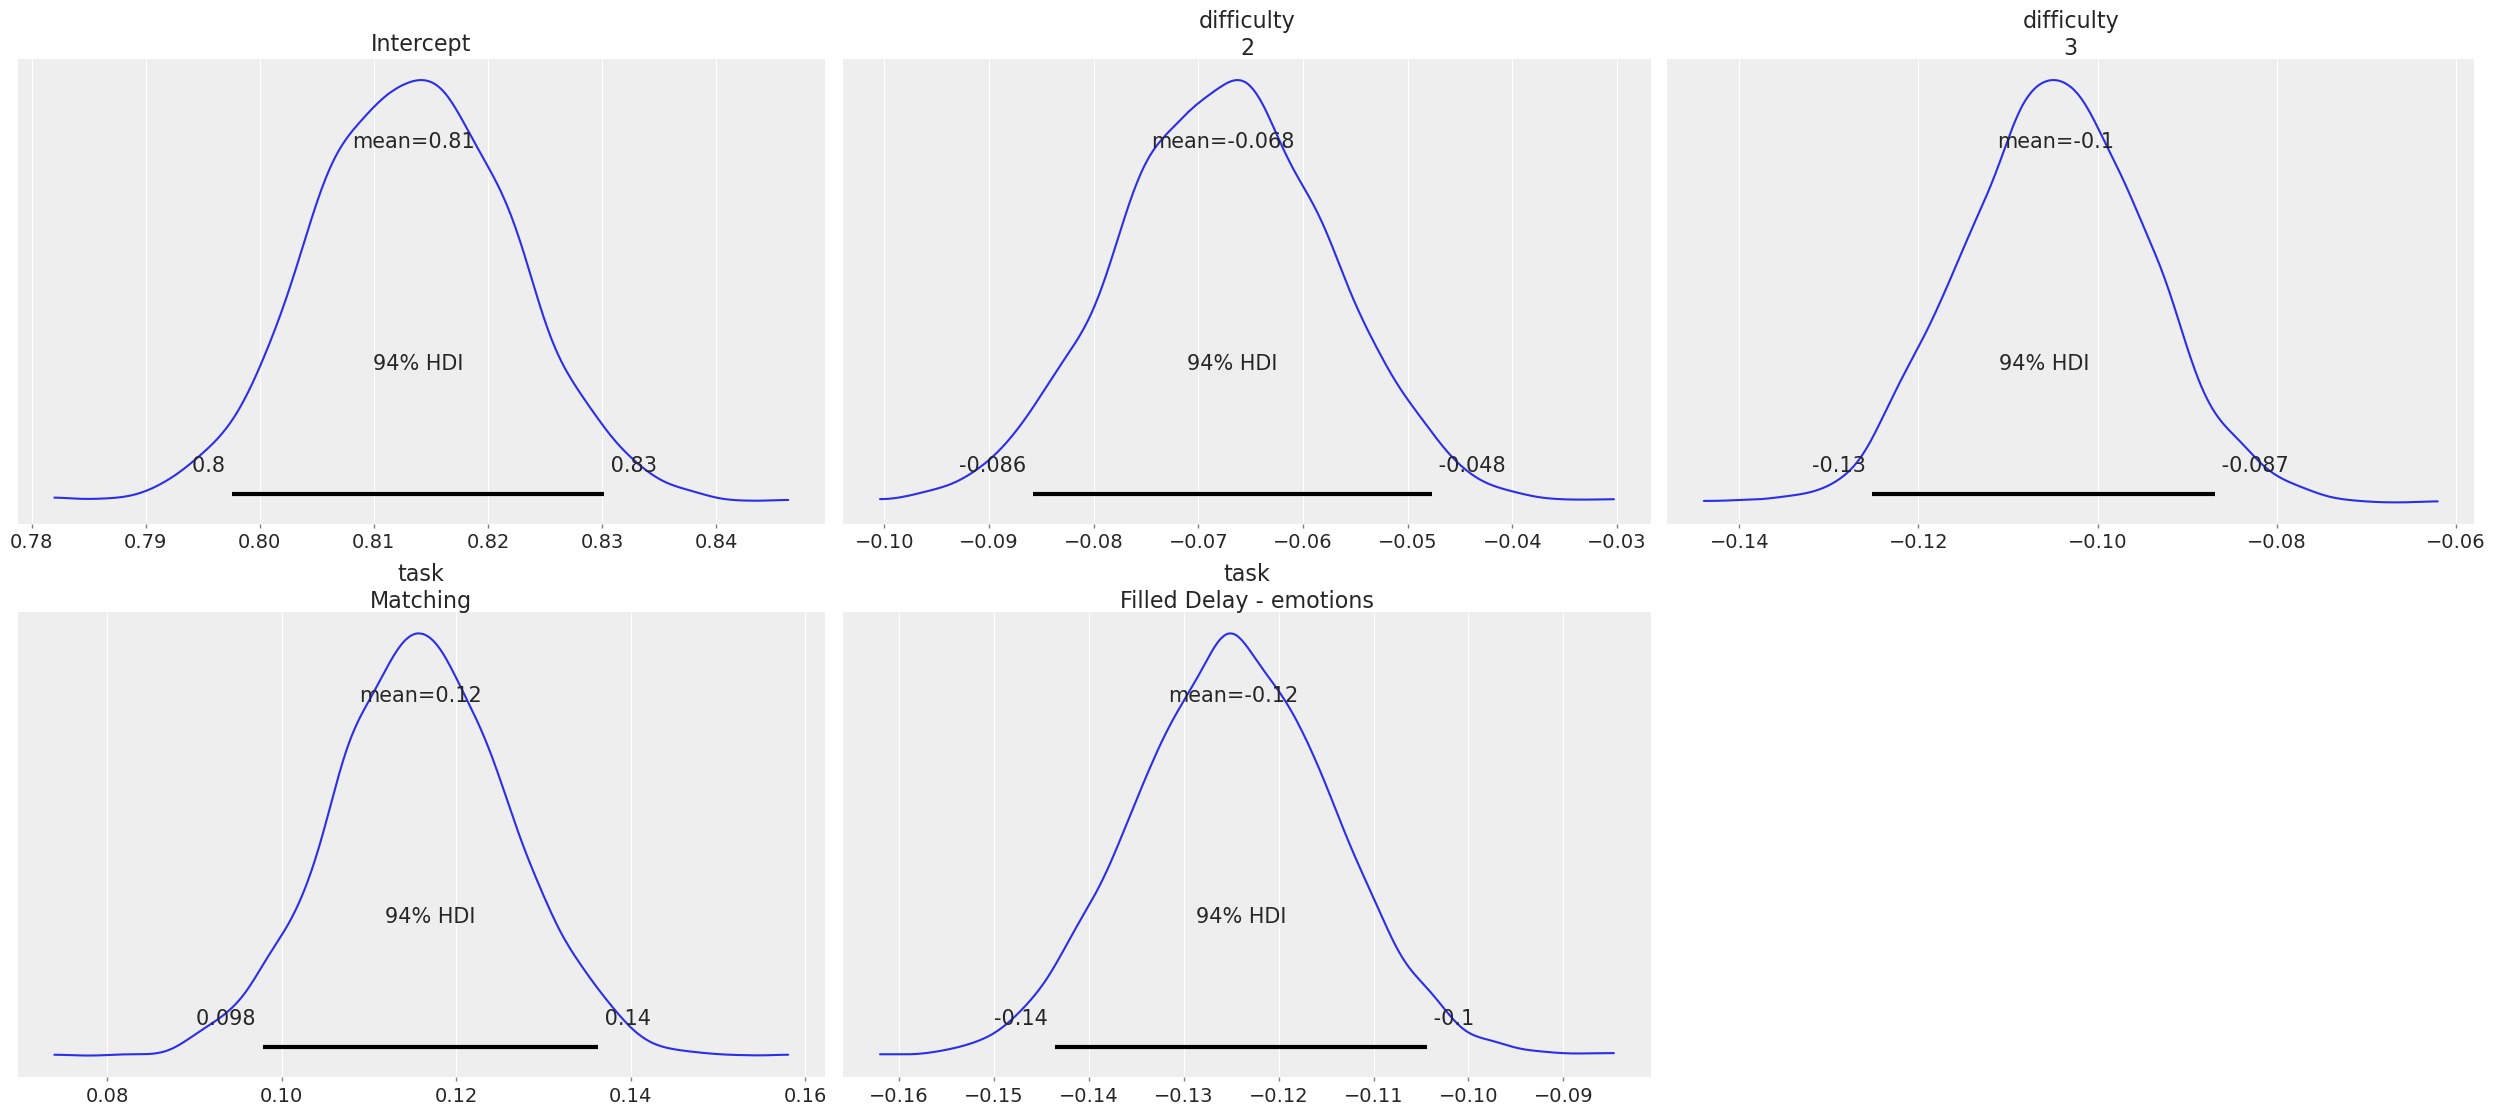

In [9]:
az.plot_posterior(result_dic_bernoulli[f][formulas2run[0]], 
                  var_names=['Intercept', 'difficulty', 'task'],#, 'task:difficulty'],
                  hdi_prob=.94)

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': 'task\nMatching'}>,
        <Axes: title={'center': 'task\nFilled Delay - emotions'}>,
        <Axes: >]], dtype=object)

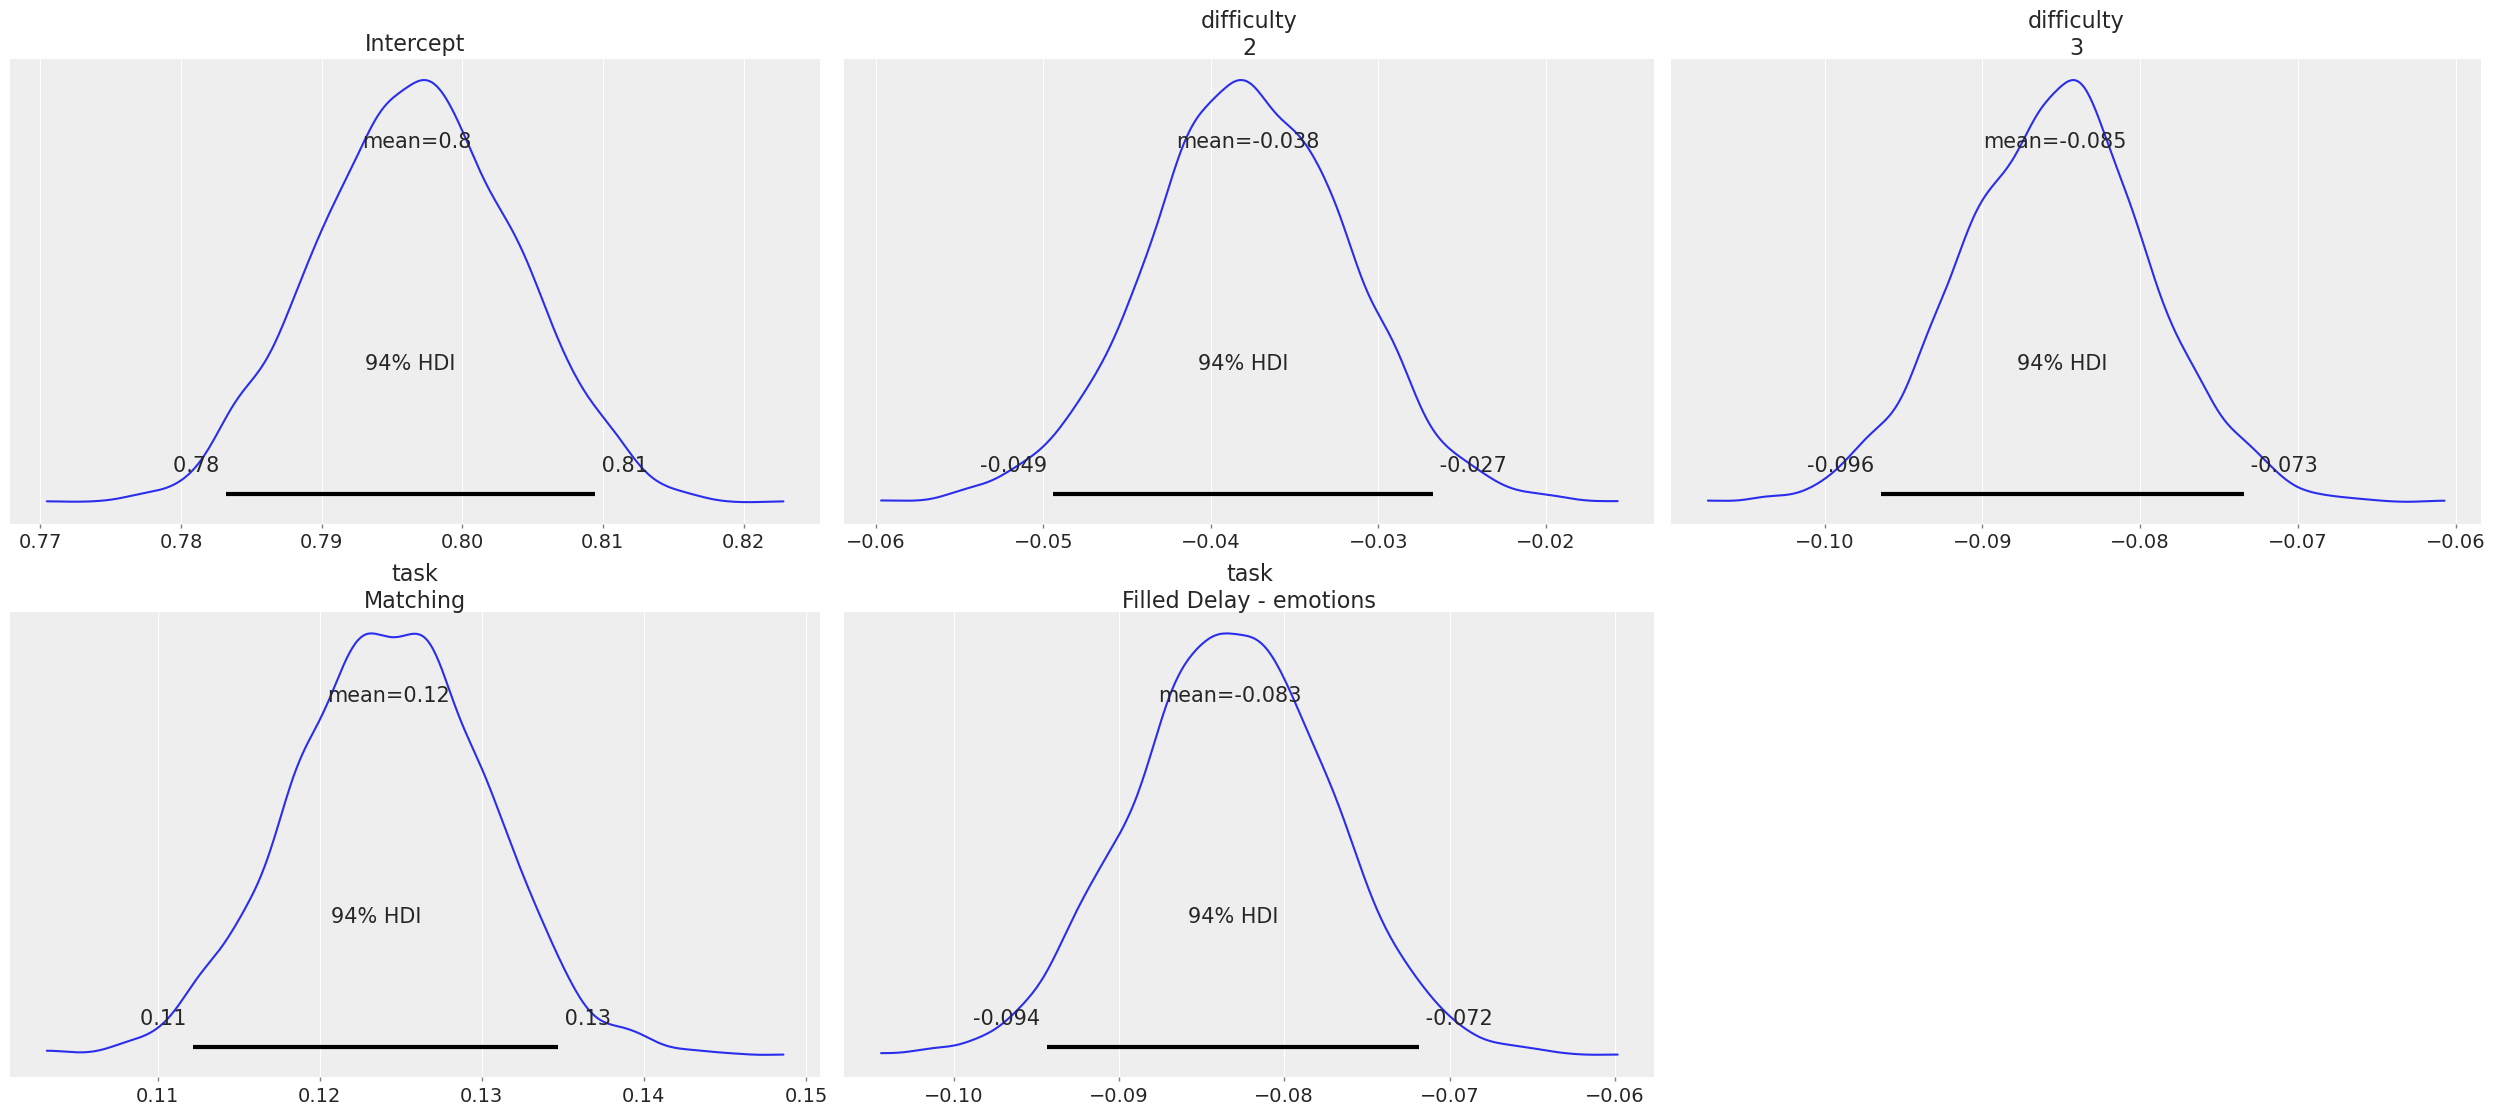

In [10]:
az.plot_posterior(result_dic_bernoulli[f][formulas2run[1]], 
                  var_names=['Intercept', 'difficulty', 'task'],#, 'task:difficulty'],
                  hdi_prob=.94)

---
## Plot results

## Dataset 3 - morphed image as cue stimulus
[top](#top)

Dataset: dataset_3_other

Fitting formula correct_flt ~ task * difficulty + (1|userID)



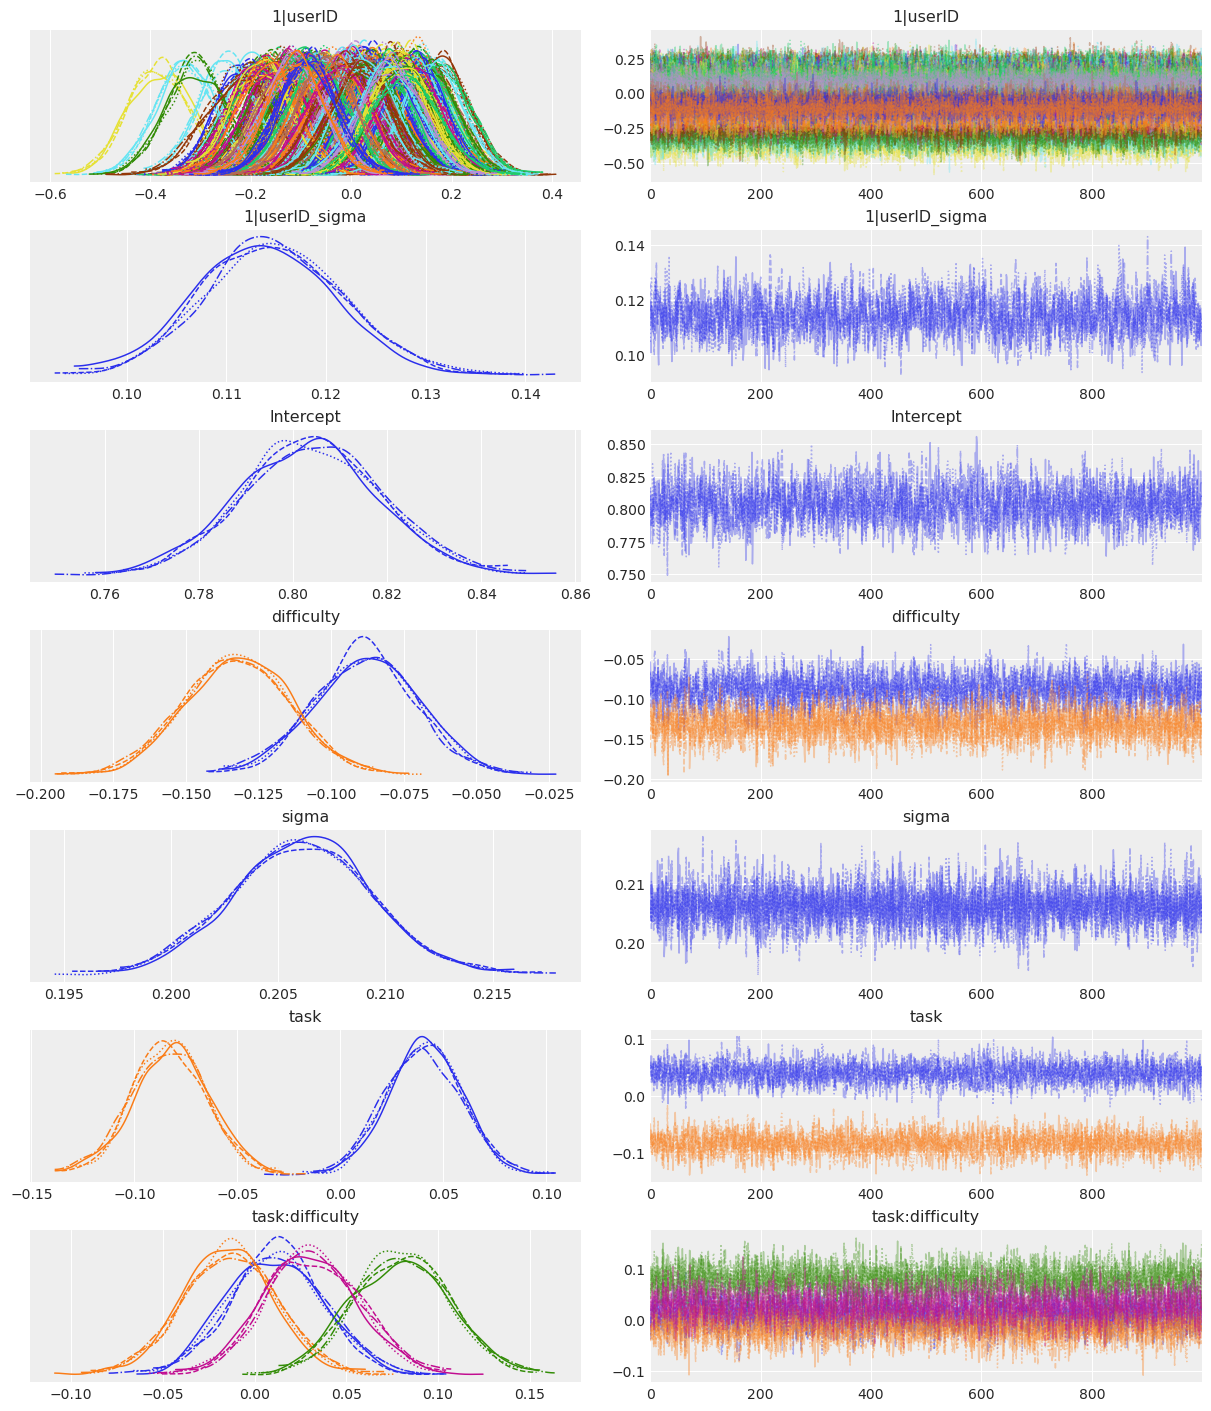

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1000]  0.036  0.058  -0.072    0.146      0.001    0.001    8387.0   
1|userID[s_1001]  0.004  0.068  -0.121    0.130      0.001    0.001    9844.0   
1|userID[s_1002] -0.142  0.059  -0.252   -0.032      0.001    0.001    8646.0   
1|userID[s_1004] -0.051  0.060  -0.160    0.065      0.001    0.001    8309.0   
1|userID[s_1019]  0.039  0.059  -0.075    0.151      0.001    0.001    8838.0   
1|userID[s_1021]  0.043  0.058  -0.070    0.148      0.001    0.001    8356.0   
1|userID[s_1023]  0.057  0.062  -0.052    0.179      0.001    0.001    7123.0   
1|userID[s_1028]  0.021  0.060  -0.091    0.138      0.001    0.001    9990.0   
1|userID[s_1029]  0.004  0.057  -0.110    0.106      0.001    0.001    7854.0   
1|userID[s_105]   0.096  0.061  -0.015    0.209      0.001    0.001    8579.0   
1|userID[s_1054] -0.056  0.060  -0.168    0.060      0.001    0.001    8297.0   
1|userID[s_1064]  0.091  0.0

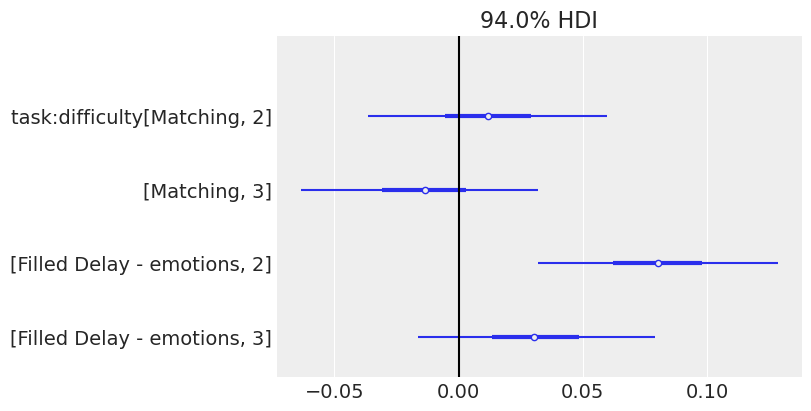

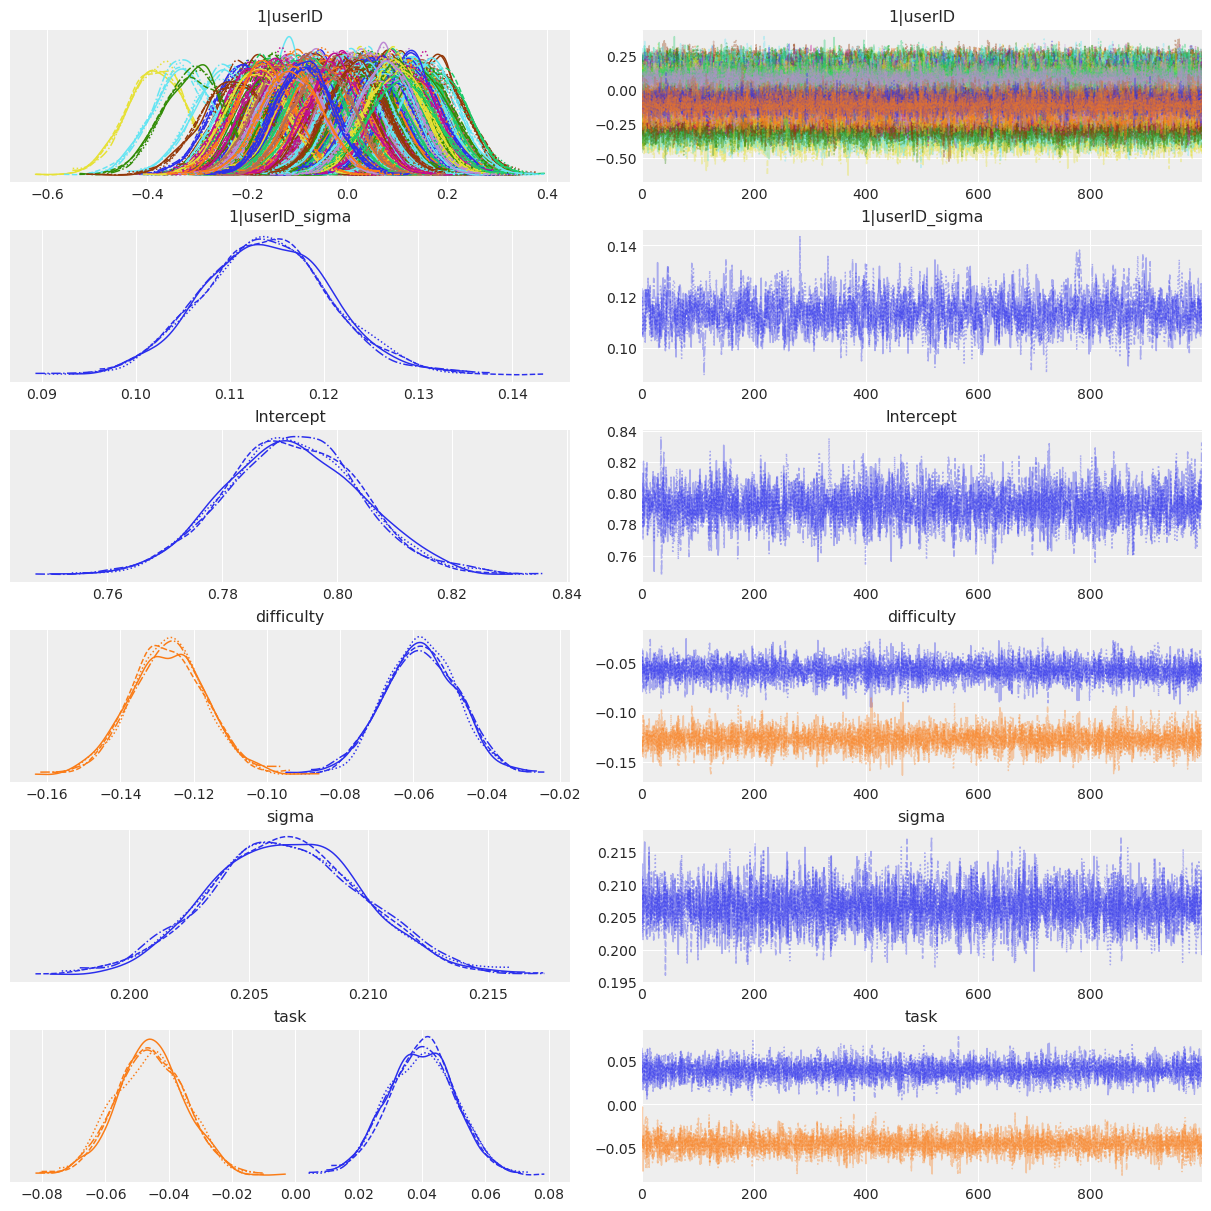

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1000]  0.034  0.060  -0.075    0.152      0.001    0.001    8341.0   
1|userID[s_1001]  0.007  0.069  -0.118    0.137      0.001    0.001    8915.0   
1|userID[s_1002] -0.143  0.059  -0.252   -0.032      0.001    0.001    7714.0   
1|userID[s_1004] -0.052  0.060  -0.161    0.067      0.001    0.001    7604.0   
1|userID[s_1019]  0.038  0.060  -0.065    0.154      0.001    0.001    9045.0   
1|userID[s_1021]  0.044  0.058  -0.065    0.157      0.001    0.001    8371.0   
1|userID[s_1023]  0.058  0.060  -0.055    0.174      0.001    0.001    8305.0   
1|userID[s_1028]  0.021  0.057  -0.086    0.125      0.001    0.001    7609.0   
1|userID[s_1029]  0.004  0.059  -0.101    0.119      0.001    0.001   10105.0   
1|userID[s_105]   0.095  0.060  -0.013    0.214      0.001    0.001    7929.0   
1|userID[s_1054] -0.056  0.059  -0.168    0.050      0.001    0.001    8772.0   
1|userID[s_1064]  0.089  0.0

In [11]:
f = 'dataset_3_other'

print(f'Dataset: {f}')
for formula in formulas2run:
    print(f'\nFitting formula {formula}\n')
    print_model(model_dic_bernoulli[f][formula], result_dic_bernoulli[f][formula])

## Dataset - unmorphed image as cue stimulus
[top](#top)

Dataset: dataset_3_target_0

Fitting formula correct_flt ~ task * difficulty + (1|userID)



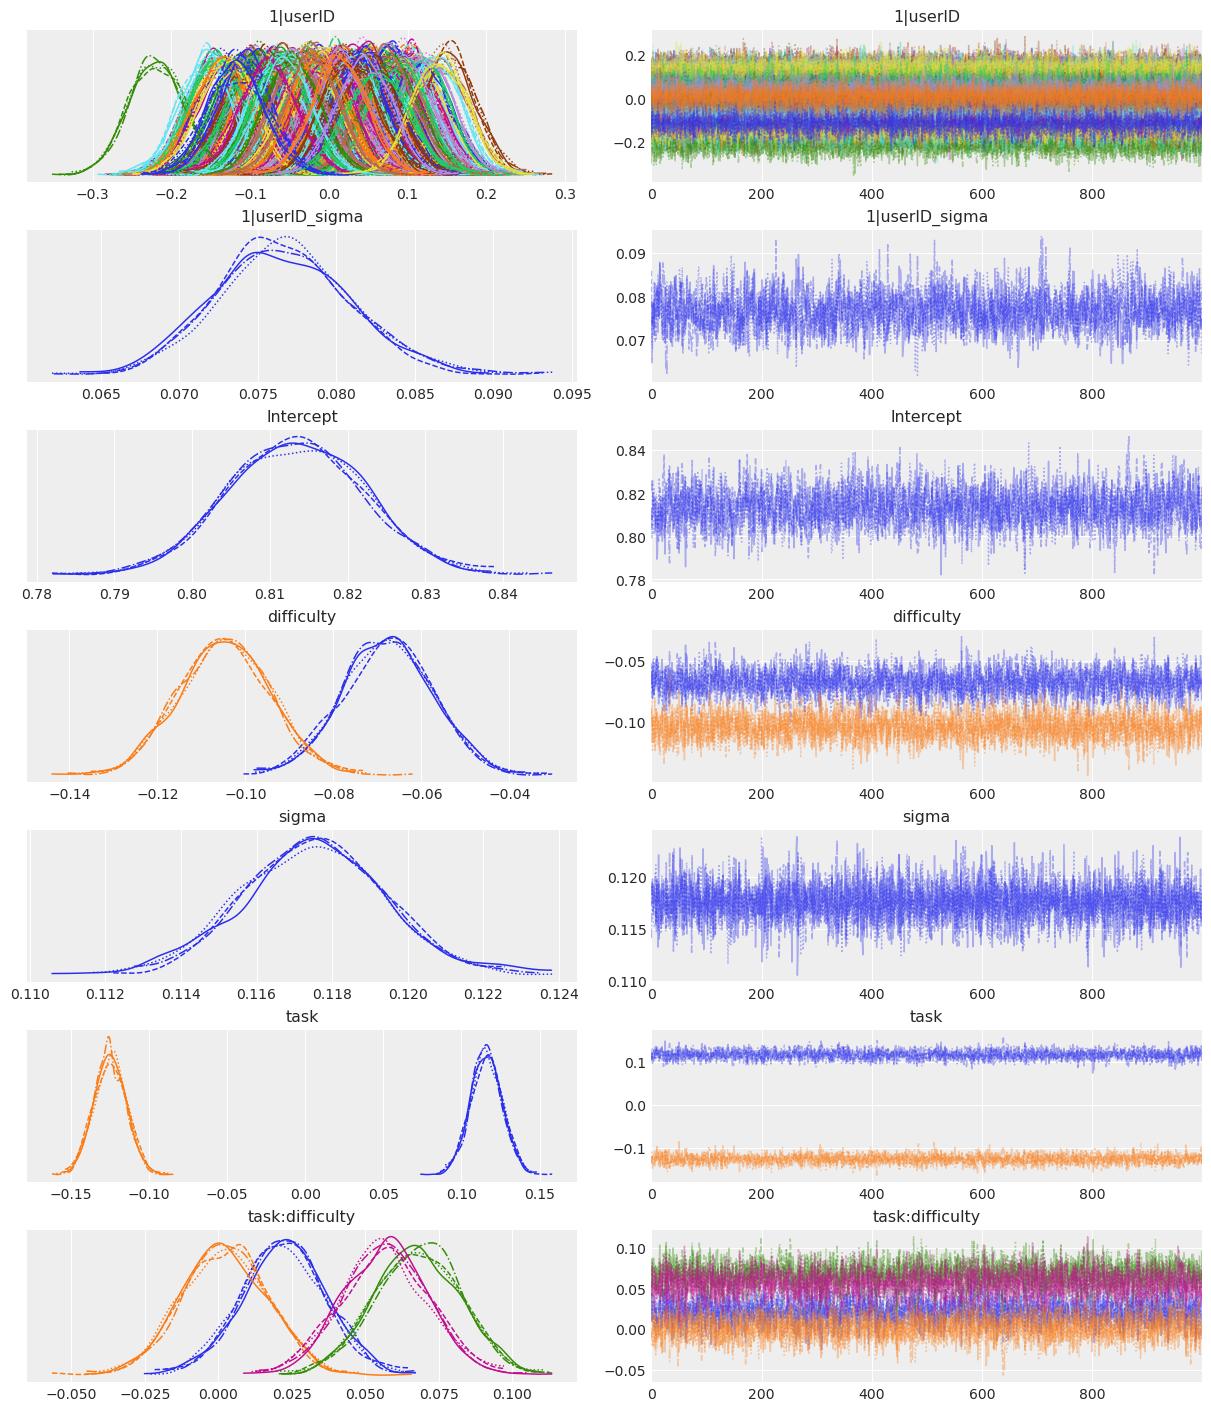

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1000]  0.023  0.035  -0.043    0.088        0.0    0.000    8135.0   
1|userID[s_1001]  0.017  0.041  -0.060    0.091        0.0    0.001    7768.0   
1|userID[s_1002] -0.089  0.035  -0.153   -0.019        0.0    0.000    7511.0   
1|userID[s_1004] -0.017  0.035  -0.084    0.049        0.0    0.001    8542.0   
1|userID[s_1019] -0.134  0.035  -0.196   -0.066        0.0    0.000    8127.0   
1|userID[s_1021] -0.086  0.035  -0.151   -0.021        0.0    0.000    7961.0   
1|userID[s_1023]  0.042  0.036  -0.026    0.106        0.0    0.000    7687.0   
1|userID[s_1028]  0.087  0.037   0.021    0.157        0.0    0.000    7874.0   
1|userID[s_1029]  0.018  0.036  -0.047    0.087        0.0    0.001    9027.0   
1|userID[s_105]   0.043  0.036  -0.025    0.108        0.0    0.000    8859.0   
1|userID[s_1054] -0.058  0.035  -0.124    0.005        0.0    0.000    8375.0   
1|userID[s_1064]  0.107  0.0

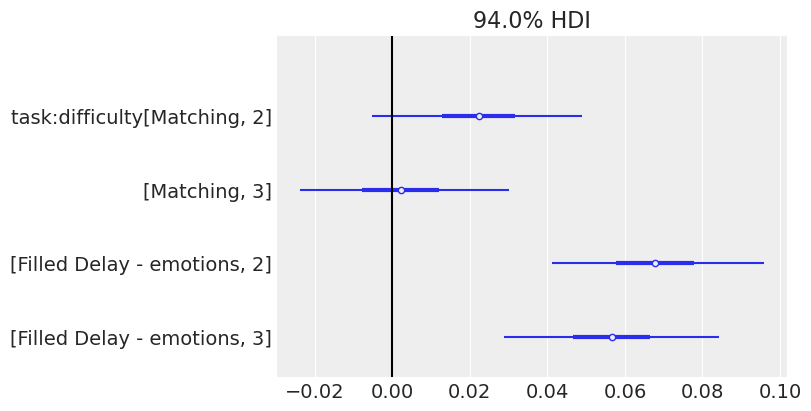

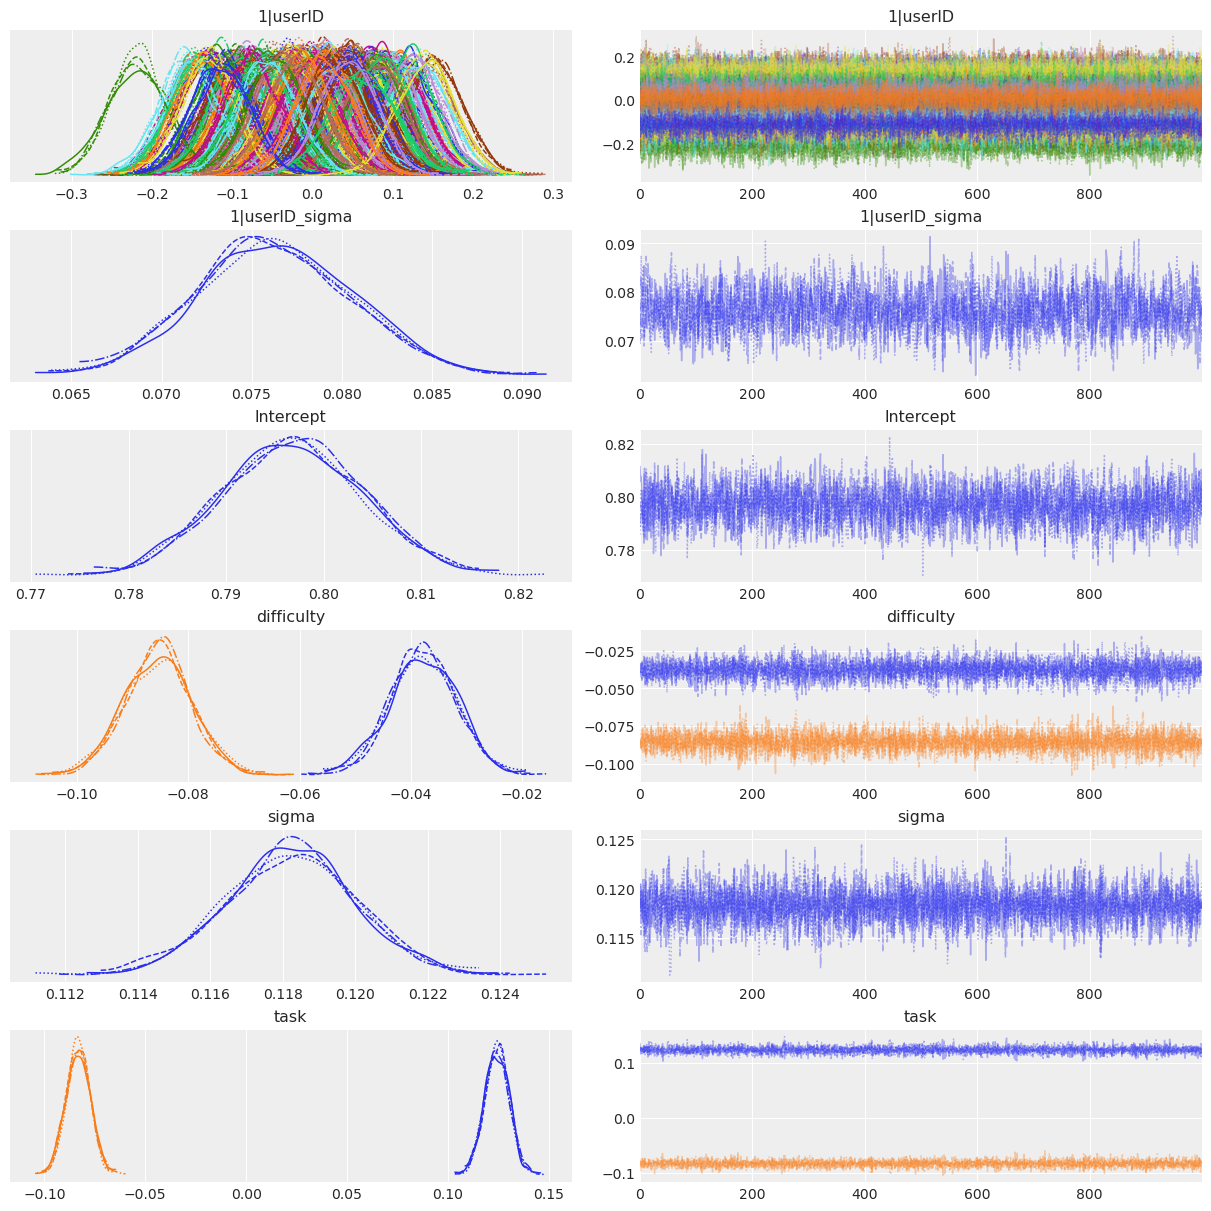

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1000]  0.022  0.036  -0.051    0.088        0.0    0.001    7641.0   
1|userID[s_1001]  0.016  0.042  -0.061    0.094        0.0    0.001    8510.0   
1|userID[s_1002] -0.089  0.035  -0.154   -0.023        0.0    0.000    5981.0   
1|userID[s_1004] -0.016  0.037  -0.086    0.052        0.0    0.001    8391.0   
1|userID[s_1019] -0.132  0.036  -0.204   -0.069        0.0    0.000    7220.0   
1|userID[s_1021] -0.086  0.035  -0.153   -0.023        0.0    0.000    7038.0   
1|userID[s_1023]  0.041  0.035  -0.020    0.109        0.0    0.000    7875.0   
1|userID[s_1028]  0.087  0.035   0.020    0.153        0.0    0.000    8496.0   
1|userID[s_1029]  0.017  0.036  -0.049    0.088        0.0    0.001    7029.0   
1|userID[s_105]   0.042  0.035  -0.024    0.107        0.0    0.000    8040.0   
1|userID[s_1054] -0.057  0.036  -0.123    0.014        0.0    0.000    7075.0   
1|userID[s_1064]  0.106  0.0

In [12]:
f = 'dataset_3_target_0'

print(f'Dataset: {f}')
for formula in formulas2run:
    print(f'\nFitting formula {formula}\n')
    print_model(model_dic_bernoulli[f][formula], result_dic_bernoulli[f][formula])

### Compare all data
[top](#top)

dataset_3_other 

                                              rank    elpd_loo       p_loo  \
correct_flt ~ task * difficulty + (1|userID)     0  270.290092  194.999914   
correct_flt ~ task + difficulty + (1|userID)     1  267.594914  190.827265   

                                              elpd_diff    weight         se  \
correct_flt ~ task * difficulty + (1|userID)   0.000000  0.686653  36.289645   
correct_flt ~ task + difficulty + (1|userID)   2.695178  0.313347  36.118060   

                                                  dse  warning scale  
correct_flt ~ task * difficulty + (1|userID)  0.00000    False   log  
correct_flt ~ task + difficulty + (1|userID)  3.82228    False   log  

dataset_3_target_0 

                                              rank     elpd_loo       p_loo  \
correct_flt ~ task * difficulty + (1|userID)     0  1578.762551  208.712826   
correct_flt ~ task + difficulty + (1|userID)     1  1566.766629  204.445716   

                                 

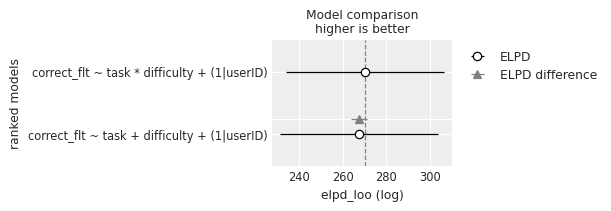

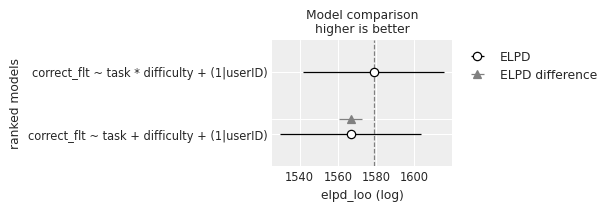

In [13]:
df_compare_formulas_bernoulli = {}
for f in result_dic_bernoulli.keys():
    print(f, '\n')
    df_compare_formulas_bernoulli[f] = az.compare(result_dic_bernoulli[f])
    
    print(df_compare_formulas_bernoulli[f])
    
    az.plot_compare(df_compare_formulas_bernoulli[f], insample_dev=False);

    
    print()
# df_compare_formulas_bernoulli[f]

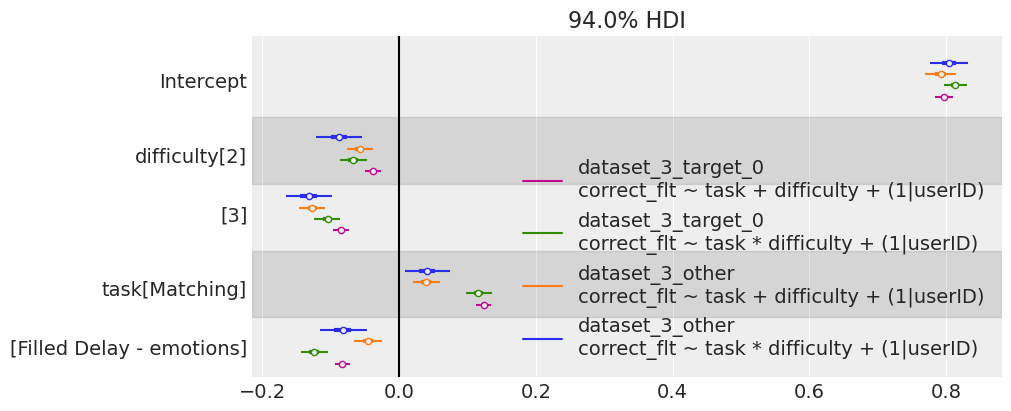

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
az.plot_forest(
    list(result_dic_bernoulli['dataset_3_other'].values())+\
    list(result_dic_bernoulli['dataset_3_target_0'].values()),
    model_names=[f'{f}\n{formula}' for f in result_dic_bernoulli.keys() for formula in formulas2run],
    var_names=["Intercept", "difficulty", "task"],
    combined=True,
    ax=ax
)

ax.axvline(0, c='k')

# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legend_handles
ax.legend(handles, labels, loc="lower right", bbox_to_anchor=(1., 0), ncols=1)
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()



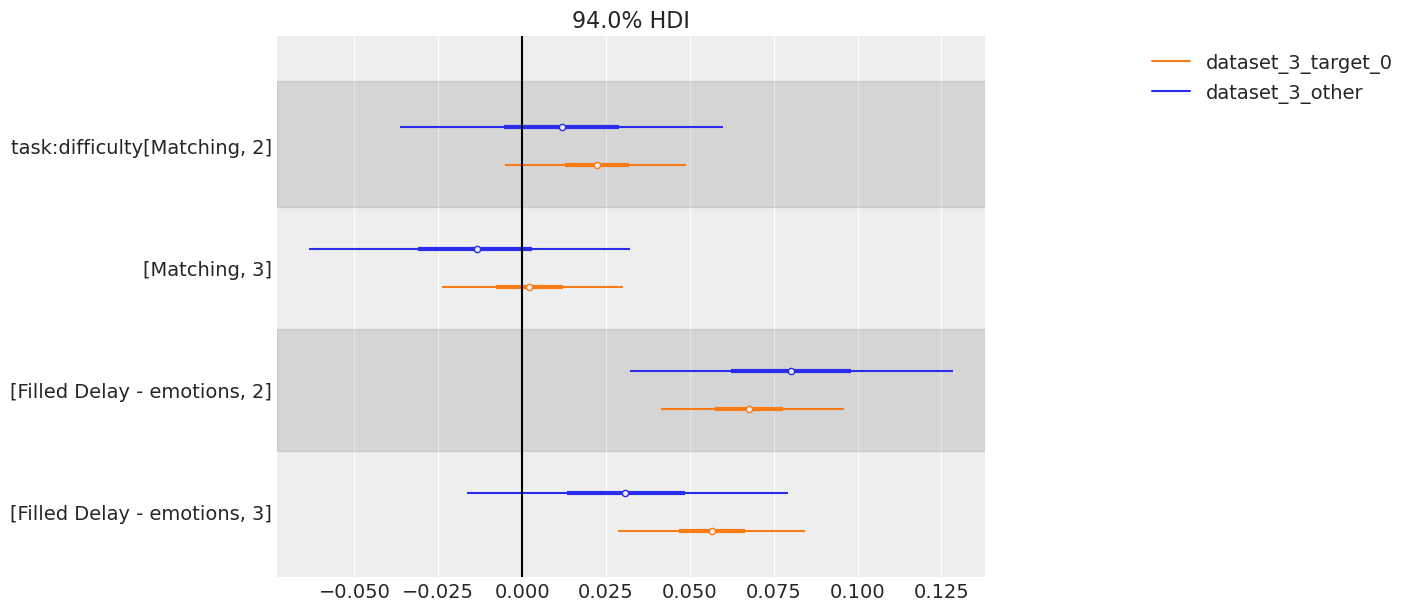

In [15]:

fig, ax = plt.subplots(figsize=(12, 6))
az.plot_forest(
    (list(result_dic_bernoulli['dataset_3_other'].values())+\
    list(result_dic_bernoulli['dataset_3_target_0'].values())
    )[::2],
    model_names=[f'{f}' for f in result_dic_bernoulli.keys()],
    var_names=["task:difficulty"],
    combined=True,
#     figsize=(12, 10)
    ax=ax
);

ax.axvline(0, c='k')

# plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
# # plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
# plt.show()


# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legend_handles
ax.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.6, 1))
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()

### Run some predictions
[top](#top)

In [16]:
# hue_order = ["face matching", "delay", "interference"]
# interactions = ['face matching, 2', 'face matching, 3', 'interference, 2', 'interference, 3']
interactions = ['Matching, 2', 'Matching, 3', 'Filled Delay - emotions, 2', 'Filled Delay - emotions, 3']
fm2, fm3, i2, i3 = [result_dic_bernoulli[f]['correct_flt ~ task * difficulty + (1|userID)'].posterior["task:difficulty"].sel({"task:difficulty_dim":tsk}) for tsk in interactions]



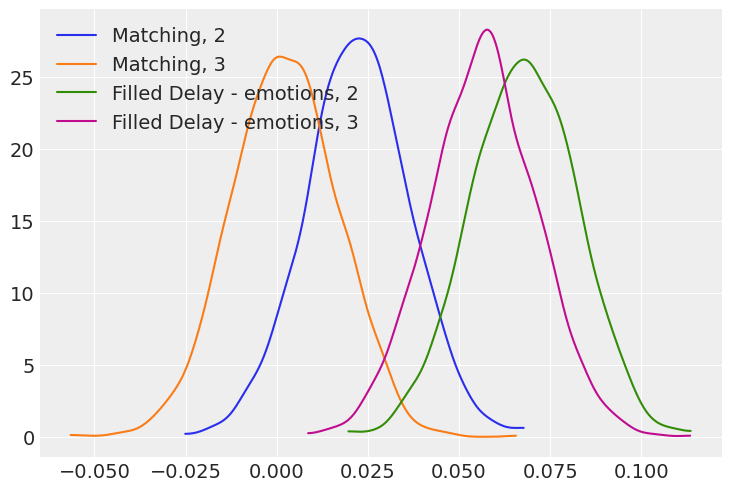

In [17]:
_, ax = plt.subplots()
for idx, x in enumerate([fm2, fm3, i2, i3]):
    az.plot_dist(x, label=x["task:difficulty_dim"].item(), plot_kwargs={"color": f"C{idx}"}, ax=ax)
ax.legend(loc="upper left");

In [18]:
# Probability that the M slope is less than 0

print(f"""
Probability that the M slope is less than 0:
level 2: {(fm2 < 0).mean().item()}
level 3: {(fm3 < 0).mean().item()}
""")


Probability that the M slope is less than 0:
level 2: 0.061
level 3: 0.44325



---

In [19]:
for f in result_dic_bernoulli.keys():

    fm2, fm3, i2, i3 = [result_dic_bernoulli[f]['correct_flt ~ task * difficulty + (1|userID)'].posterior["task:difficulty"].sel({"task:difficulty_dim":tsk}) for tsk in interactions]
    print(f"""
Experiment {f}:
  Probability that the M slope is less than 0:
    level 2: {(fm2 < 0).mean().item()}
    level 3: {(fm3 < 0).mean().item()}
    
  Probability that the FD-e slope is less than 0:
    level 2: {(i2 < 0).mean().item()}
    level 3: {(i3 < 0).mean().item()}
    
    """)


Experiment dataset_3_other:
  Probability that the M slope is less than 0:
    level 2: 0.32825
    level 3: 0.7065
    
  Probability that the FD-e slope is less than 0:
    level 2: 0.0005
    level 3: 0.10625
    
    

Experiment dataset_3_target_0:
  Probability that the M slope is less than 0:
    level 2: 0.061
    level 3: 0.44325
    
  Probability that the FD-e slope is less than 0:
    level 2: 0.0
    level 3: 0.0
    
    


### Save the inference
[top](#top)

It could be possible to use this:
```
result_dic_bernoulli['dataset_3_other']['correct_flt ~ task * difficulty + (1|userID)'].to_netcdf()
```

and the other datasets that were fitted, but it doesn't preserve the dictionary, so I use pickle.

In [20]:
# save the dictionary to a pickle file
with open(opj(path_inference_data,'FMP_Figure_4_cue_stim_inference_data_dict.pkl'), 'wb') as f:
    pickle.dump(result_dic_bernoulli, f)

In [21]:
# # Load the dictionary from the pickle file
# with open(opj(path_inference_data,'FMP_Figure_4_cue_stim_inference_data_dict.pkl'), 'rb') as f:
#     loaded_inference_data_dict = pickle.load(f)


In [22]:
%load_ext watermark

%watermark -a 'Jan Kadlec' -nmvu -iv -iv -w -p pytensor


Author: Jan Kadlec

Last updated: Wed Feb 05 2025

Python implementation: CPython
Python version       : 3.12.5
IPython version      : 8.25.0

pytensor: 2.23.0

Compiler    : GCC 12.4.0
OS          : Linux
Release     : 5.14.0-427.42.1.el9_4.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 96
Architecture: 64bit

arviz     : 0.19.0
bambi     : 0.14.0
matplotlib: 3.9.2
sys       : 3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:36:51) [GCC 12.4.0]
numpy     : 1.26.4
pandas    : 2.2.2

Watermark: 2.4.3



[top](#top)